## Part 1: Theory Questions (15 points)

In [ ]:
3. What are outliers and how can they impact your analysis?

Outliers are data points that are much higher or lower than other data points.
They can affect averages and make analysis incorrect or misleading.
That is why outliers should be checked before analysis.

In [ ]:
4. What is the difference between correlation and causation?

Correlation means two things are related or move together.
Causation means one thing directly causes the other to happen.
Correlation does not always mean causation.

In [ ]:
5. Why is data visualization important in presenting analysis results?

Data visualization makes data easier to understand using charts and graphs.
It helps people quickly see patterns, trends, and important insights.
It also makes reports more clear and attractive.

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

## Part 2: Data Loading & Exploration (20 points)

In [3]:
# 6.Load the sales_data.csv file into a Pandas DataFrame

df = pd.read_csv(r"C:\Users\Rupali\Downloads\sales_data.csv")

In [4]:
df

,transaction_id,date,product,category,quantity,price,discount
0,TXN1074,2024-03-08,Desk Lamp,Accessories,5,27.78,0.20
1,TXN1019,2024-03-21,Keyboard,Peripherals,3,126.92,0.05
2,TXN1119,2024-01-06,USB Cable,Accessories,2,5.12,0.15
3,TXN1079,2024-01-01,Webcam,Peripherals,2,46.79,0.20
4,TXN1077,2024-02-24,Webcam,Peripherals,2,31.77,0.15
...,...,...,...,...,...,...,...
145,TXN1072,2024-03-10,Webcam,Peripherals,3,38.89,NaN
146,TXN1107,2024-02-27,Webcam,Peripherals,2,60.91,0.15
147,TXN1015,2024-01-14,Monitor,Electronics,4,213.57,0.15
148,TXN1093,2024-02-04,Mouse,Peripherals,1,37.95,0.15


In [6]:
# 7.Display the first 5 rows and basic information about the dataset

df.head()

,transaction_id,date,product,category,quantity,price,discount
0,TXN1074,2024-03-08,Desk Lamp,Accessories,5,27.78,0.20
1,TXN1019,2024-03-21,Keyboard,Peripherals,3,126.92,0.05
2,TXN1119,2024-01-06,USB Cable,Accessories,2,5.12,0.15
3,TXN1079,2024-01-01,Webcam,Peripherals,2,46.79,0.20
4,TXN1077,2024-02-24,Webcam,Peripherals,2,31.77,0.15


In [7]:
print(f"Rows : {df.shape[0]} ,column : {df.shape[1]}")

Rows : 150 ,column : 7


In [8]:
df.tail()

,transaction_id,date,product,category,quantity,price,discount
145,TXN1072,2024-03-10,Webcam,Peripherals,3,38.89,NaN
146,TXN1107,2024-02-27,Webcam,Peripherals,2,60.91,0.15
147,TXN1015,2024-01-14,Monitor,Electronics,4,213.57,0.15
148,TXN1093,2024-02-04,Mouse,Peripherals,1,37.95,0.15
149,TXN1103,2024-03-11,External SSD,Storage,4,194.01,0.10


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transaction_id  150 non-null    object 
 1   date            150 non-null    object 
 2   product         150 non-null    object 
 3   category        150 non-null    object 
 4   quantity        150 non-null    int64  
 5   price           150 non-null    float64
 6   discount        119 non-null    float64
dtypes: float64(2), int64(1), object(4)
memory usage: 8.3+ KB


In [10]:
# 9.Identify and report the data type of each column

df.dtypes

transaction_id     object
date               object
product            object
category           object
quantity            int64
price             float64
discount          float64
dtype: object

In [11]:
df.describe()

,quantity,price,discount
count,150.000000,150.000000,119.000000
mean,3.040000,222.388800,0.106723
std,1.418384,343.261197,0.068866
min,1.000000,5.120000,0.000000
25%,2.000000,34.890000,0.050000
50%,3.000000,91.245000,0.100000
75%,4.000000,198.687500,0.150000
max,5.000000,1420.630000,0.200000


In [12]:
# 8.Check for missing values and report the count in each column

df.isnull().sum()

transaction_id     0
date               0
product            0
category           0
quantity           0
price              0
discount          31
dtype: int64

In [13]:
# Unique value
# 10.Calculate the total number of records and unique products in the dataset

print(df["product"].nunique())
print(df["category"].nunique())

10
4


In [14]:
# 
df["product"].value_counts()

product
Monitor         21
Keyboard        19
Headphones      17
Laptop          16
Webcam          15
Mouse           14
External SSD    13
Desk Lamp       12
USB Cable       12
Phone Stand     11
Name: count, dtype: int64

In [15]:
df["category"].value_counts()

category
Accessories    52
Peripherals    48
Electronics    37
Storage        13
Name: count, dtype: int64

In [16]:
# Date Range :
print(f"Date Range : {df["date"].min()} to {df["date"].max()}")

Date Range : 2024-01-01 to 2024-03-30


## Part 3: Data Cleaning & Preprocessing (20 points)

In [17]:
df1 = df.copy()

In [18]:
df1

,transaction_id,date,product,category,quantity,price,discount
0,TXN1074,2024-03-08,Desk Lamp,Accessories,5,27.78,0.20
1,TXN1019,2024-03-21,Keyboard,Peripherals,3,126.92,0.05
2,TXN1119,2024-01-06,USB Cable,Accessories,2,5.12,0.15
3,TXN1079,2024-01-01,Webcam,Peripherals,2,46.79,0.20
4,TXN1077,2024-02-24,Webcam,Peripherals,2,31.77,0.15
...,...,...,...,...,...,...,...
145,TXN1072,2024-03-10,Webcam,Peripherals,3,38.89,NaN
146,TXN1107,2024-02-27,Webcam,Peripherals,2,60.91,0.15
147,TXN1015,2024-01-14,Monitor,Electronics,4,213.57,0.15
148,TXN1093,2024-02-04,Mouse,Peripherals,1,37.95,0.15


In [19]:
# 11.Handle missing values in the 'discount' column by replacing with the median value.

df1["discount"] = df1["discount"].fillna(df1["discount"].median())

In [20]:
df1.isnull().sum()

transaction_id    0
date              0
product           0
category          0
quantity          0
price             0
discount          0
dtype: int64

In [21]:
# 12.Convert the 'date' column to datetime format
df1["date"] = pd.to_datetime(df1["date"])

In [22]:
df1.dtypes

transaction_id            object
date              datetime64[ns]
product                   object
category                  object
quantity                   int64
price                    float64
discount                 float64
dtype: object

In [23]:
# 13.Create a new column 'month' extracted from the date
df1["month"] = df1["date"].dt.to_period("M")

In [24]:
df1

,transaction_id,date,product,category,quantity,price,discount,month
0,TXN1074,2024-03-08,Desk Lamp,Accessories,5,27.78,0.20,2024-03
1,TXN1019,2024-03-21,Keyboard,Peripherals,3,126.92,0.05,2024-03
2,TXN1119,2024-01-06,USB Cable,Accessories,2,5.12,0.15,2024-01
3,TXN1079,2024-01-01,Webcam,Peripherals,2,46.79,0.20,2024-01
4,TXN1077,2024-02-24,Webcam,Peripherals,2,31.77,0.15,2024-02
...,...,...,...,...,...,...,...,...
145,TXN1072,2024-03-10,Webcam,Peripherals,3,38.89,0.10,2024-03
146,TXN1107,2024-02-27,Webcam,Peripherals,2,60.91,0.15,2024-02
147,TXN1015,2024-01-14,Monitor,Electronics,4,213.57,0.15,2024-01
148,TXN1093,2024-02-04,Mouse,Peripherals,1,37.95,0.15,2024-02


In [25]:
# extracting only year

df1["date"].dt.year

0      2024
1      2024
2      2024
3      2024
4      2024
       ... 
145    2024
146    2024
147    2024
148    2024
149    2024
Name: date, Length: 150, dtype: int32

In [26]:
df1["date"].dt.month

0      3
1      3
2      1
3      1
4      2
      ..
145    3
146    2
147    1
148    2
149    3
Name: date, Length: 150, dtype: int32

In [27]:
df1.duplicated().sum()

np.int64(0)

In [28]:
# 14.Remove any duplicate rows

df1 = df1.drop_duplicates()

In [29]:
# 15.Create a 'revenue' column calculated as: quantity × price × (1 - discount)

df1["revenue"] = df1["quantity"] * df1["price"] * (1 - df1["discount"])

In [30]:
df1

,transaction_id,date,product,category,quantity,price,discount,month,revenue
0,TXN1074,2024-03-08,Desk Lamp,Accessories,5,27.78,0.20,2024-03,111.1200
1,TXN1019,2024-03-21,Keyboard,Peripherals,3,126.92,0.05,2024-03,361.7220
2,TXN1119,2024-01-06,USB Cable,Accessories,2,5.12,0.15,2024-01,8.7040
3,TXN1079,2024-01-01,Webcam,Peripherals,2,46.79,0.20,2024-01,74.8640
4,TXN1077,2024-02-24,Webcam,Peripherals,2,31.77,0.15,2024-02,54.0090
...,...,...,...,...,...,...,...,...,...
145,TXN1072,2024-03-10,Webcam,Peripherals,3,38.89,0.10,2024-03,105.0030
146,TXN1107,2024-02-27,Webcam,Peripherals,2,60.91,0.15,2024-02,103.5470
147,TXN1015,2024-01-14,Monitor,Electronics,4,213.57,0.15,2024-01,726.1380
148,TXN1093,2024-02-04,Mouse,Peripherals,1,37.95,0.15,2024-02,32.2575


## Part 4: Exploratory Data Analysis (20 points)

In [31]:
# 16.Summary statistics (mean, median, std) for 'quantity', 'price', and 'revenue'

df1[["quantity","price","revenue"]].describe()

,quantity,price,revenue
count,150.000000,150.000000,150.000000
mean,3.040000,222.388800,608.123783
std,1.418384,343.261197,1035.827065
min,1.000000,5.120000,6.184500
25%,2.000000,34.890000,68.846000
50%,3.000000,91.245000,183.535750
75%,4.000000,198.687500,650.973000
max,5.000000,1420.630000,5114.268000


In [32]:
df1[["quantity","price","revenue"]].agg(["mean","median","std"])

,quantity,price,revenue
mean,3.040000,222.388800,608.123783
median,3.000000,91.245000,183.535750
std,1.418384,343.261197,1035.827065


In [33]:
# 17.Total revenue and average transaction value
df1["revenue"].sum()

np.float64(91218.5675)

In [34]:
df1["revenue"].mean()

np.float64(608.1237833333333)

In [35]:
# 18.Top 5 products by total revenue

df1.groupby("product")["revenue"].sum().sort_values(ascending = False).head(5)

product
Laptop          47252.4870
Monitor         22222.9490
External SSD     6533.1915
Headphones       5624.8570
Keyboard         4743.7425
Name: revenue, dtype: float64

In [36]:
# 19.Sales by category (count and total revenue)

df1.groupby("category")["revenue"].sum()

category
Accessories     7705.9800
Electronics    69475.4360
Peripherals     7503.9600
Storage         6533.1915
Name: revenue, dtype: float64

In [37]:
df1.groupby("category")["revenue"].count()

category
Accessories    52
Electronics    37
Peripherals    48
Storage        13
Name: revenue, dtype: int64

In [38]:
df1.groupby("category").agg(total_revenue=("revenue", "sum"),
    sales_count=("revenue", "count"))

,total_revenue,sales_count
category,,
Accessories,7705.9800,52
Electronics,69475.4360,37
Peripherals,7503.9600,48
Storage,6533.1915,13


In [39]:
# 20.Monthly revenue trend (total revenue for each month)

df1.groupby("month")["revenue"].sum()

month
2024-01    34600.6015
2024-02    29722.2325
2024-03    26895.7335
Freq: M, Name: revenue, dtype: float64

In [40]:
# 21.Correlation between quantity and revenue

df1["quantity"].corr(df1["revenue"])


np.float64(0.30140755119593526)

In [41]:
df1

,transaction_id,date,product,category,quantity,price,discount,month,revenue
0,TXN1074,2024-03-08,Desk Lamp,Accessories,5,27.78,0.20,2024-03,111.1200
1,TXN1019,2024-03-21,Keyboard,Peripherals,3,126.92,0.05,2024-03,361.7220
2,TXN1119,2024-01-06,USB Cable,Accessories,2,5.12,0.15,2024-01,8.7040
3,TXN1079,2024-01-01,Webcam,Peripherals,2,46.79,0.20,2024-01,74.8640
4,TXN1077,2024-02-24,Webcam,Peripherals,2,31.77,0.15,2024-02,54.0090
...,...,...,...,...,...,...,...,...,...
145,TXN1072,2024-03-10,Webcam,Peripherals,3,38.89,0.10,2024-03,105.0030
146,TXN1107,2024-02-27,Webcam,Peripherals,2,60.91,0.15,2024-02,103.5470
147,TXN1015,2024-01-14,Monitor,Electronics,4,213.57,0.15,2024-01,726.1380
148,TXN1093,2024-02-04,Mouse,Peripherals,1,37.95,0.15,2024-02,32.2575


## Part 5: Data Visualization (15 points)

### Create the following visualizations using Matplotlib/Seaborn:

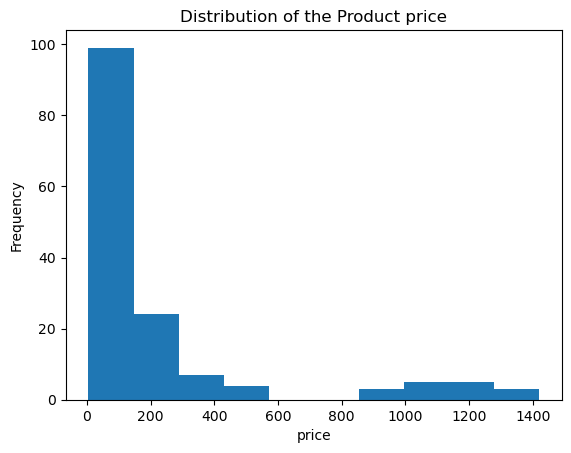

In [42]:
#22.Histogram: Distribution of product prices

plt.hist(df1["price"], bins = 10)
plt.title("Distribution of the Product price")
plt.xlabel("price")
plt.ylabel("Frequency")
plt.show()

In [43]:
# 23.Bar chart: Revenue by category

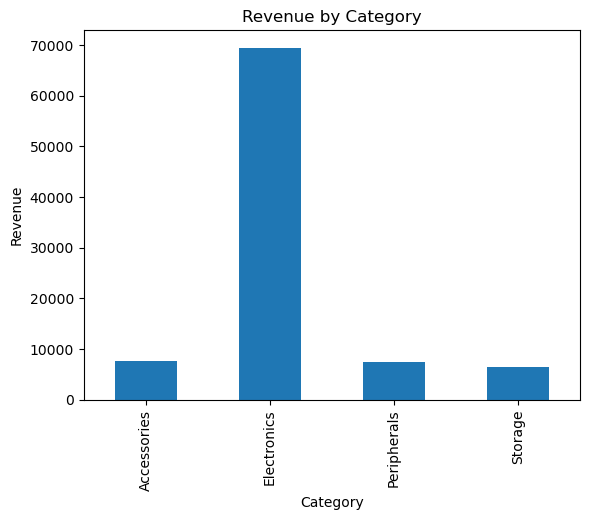

In [44]:
df1.groupby("category")["revenue"].sum().plot(kind="bar")
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.show()

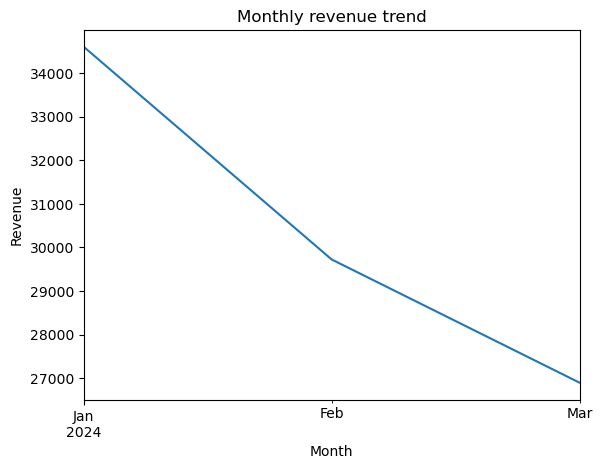

In [45]:
# 24.Line plot: Monthly revenue trend

df1.groupby("month")["revenue"].sum().plot(kind = "line")
plt.title("Monthly revenue trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

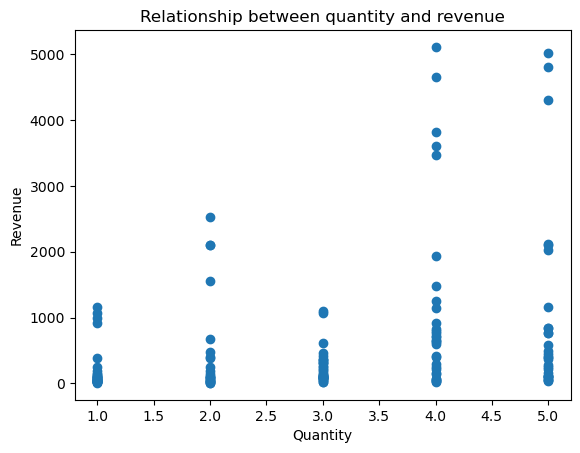

In [46]:
# 25.Scatter plot: Relationship between quantity and revenue

plt.scatter(df1["quantity"],df1["revenue"])
plt.title("Relationship between quantity and revenue")
plt.xlabel("Quantity")
plt.ylabel("Revenue")
plt.show()

In [47]:
df1["quantity"].value_counts()

quantity
3    33
4    32
1    31
5    30
2    24
Name: count, dtype: int64

## Part 6: Business Insights & Recommendations (10 points)